# Leakage prediction by layer and user-token position

This notebook predicts `attack_successful` from the stored Top-15 J-Lens readouts. It uses no secret probe features and no metadata as model inputs.

A separate L2 logistic regression is evaluated for every combination of layer and relative user-message position. `category` is used only to create GroupKFold splits.

In [1]:
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn xgboost


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: /Users/christinck/Documents/j-lens-capstone/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack, lil_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Find the repository root whether the notebook runs from the repo or its folder.
ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "outputs").exists()
)
INPUT_FILE = (
    ROOT / "outputs" / "j-lens-run" /
    "qwen35-4b-full-corpus-user-positions.jsonl"
)

# This first pass uses only the second half of the model's layers.
ANALYSIS_LAYERS = list(range(16, 32))
TOP_K = 15
MIN_TOKEN_DF = 5
MAX_TOKEN_FEATURES = 200
N_SPLITS = 6
RANDOM_STATE = 42

# Percentage regions adapt to user messages of different token lengths.
POSITION_REGIONS = {
    "0–20%": (0.0, 0.2),
    "20–40%": (0.2, 0.4),
    "40–60%": (0.4, 0.6),
    "60–80%": (0.6, 0.8),
    "80–90%": (0.8, 0.9),
    "penultimate": "penultimate",
    "last": "last",
}
POSITION_ORDER = list(POSITION_REGIONS)

## Load the full-corpus run

In [3]:
with INPUT_FILE.open(encoding="utf-8") as file:
    examples = [json.loads(line) for line in file if line.strip()]

assert len(examples) == 440
assert all(example["readout_scope"] == "user" for example in examples)

first_position = next(iter(examples[0]["readouts"].values()))
first_layer = next(iter(first_position["layers"].values()))
assert len(first_layer["top_k"]["token_ids"]) >= TOP_K

overview = pd.DataFrame({
    "dataset": ["all", "attacks", "benign"],
    "runs": [
        len(examples),
        sum(example["label"] == "attack" for example in examples),
        sum(example["label"] == "benign" for example in examples),
    ],
    "leaked": [
        sum(example["attack_successful"] for example in examples),
        sum(
            example["attack_successful"]
            for example in examples if example["label"] == "attack"
        ),
        sum(
            example["attack_successful"]
            for example in examples if example["label"] == "benign"
        ),
    ],
})
display(overview)

,dataset,runs,leaked
0,all,440,152
1,attacks,308,145
2,benign,132,7


## Extract Top-15 features

For a percentage region, repeated token IDs are pooled with their maximum logit across positions. The 15 rank slots also contribute their maximum and mean logits. The last two positions are evaluated individually.

In [4]:
def select_positions(example, region):
    # The stored positions already refer only to the user-message tokens.
    positions = sorted(int(position) for position in example["readouts"])
    if region == "last":
        return positions[-1:]
    if region == "penultimate":
        return positions[-2:-1]

    # Convert a relative region such as 60–80% into concrete token indices.
    lower, upper = region
    start = math.floor(lower * len(positions))
    end = math.floor(upper * len(positions))
    return positions[start:end]


def extract_records(examples, layer, region):
    # Build one classifier record per prompt for one layer × position region.
    records = []
    for example in examples:
        positions = select_positions(example, region)
        if not positions:
            continue

        # Pool repeated tokens with their strongest logit within the region.
        token_max_logits = {}
        token_text = {}
        rank_logits = [[] for _ in range(TOP_K)]

        for position in positions:
            top_k = example["readouts"][str(position)]["layers"][str(layer)]["top_k"]
            for rank, (token_id, token, logit) in enumerate(zip(
                top_k["token_ids"][:TOP_K],
                top_k["tokens"][:TOP_K],
                top_k["logits"][:TOP_K],
            )):
                token_max_logits[token_id] = max(
                    token_max_logits.get(token_id, -np.inf), logit
                )
                token_text[token_id] = token
                rank_logits[rank].append(logit)

        # Category is retained only as the cross-validation group.
        records.append({
            "id": example["id"],
            "label": example["label"],
            "target": int(example["attack_successful"]),
            "group": example["category"],
            "token_max_logits": token_max_logits,
            "token_text": token_text,
            "rank_max": [max(values) for values in rank_logits],
            "rank_mean": [float(np.mean(values)) for values in rank_logits],
        })

    return records

## Fold-local sparse matrices

Token vocabulary selection happens only on the training fold. `category` determines the fold but is never added to the feature matrix.

In [5]:
def select_vocabulary(records, train_indices):
    # Select tokens on the training fold only, avoiding test-fold leakage.
    document_frequency = Counter()
    for index in train_indices:
        document_frequency.update(records[index]["token_max_logits"].keys())

    candidates = [
        token_id for token_id, count in document_frequency.items()
        if count >= MIN_TOKEN_DF
    ]
    candidates.sort(key=lambda token_id: (-document_frequency[token_id], token_id))
    return candidates[:MAX_TOKEN_FEATURES]


def build_matrix(records, indices, vocabulary):
    # Dense block: maximum and mean logit at each of the 15 rank slots.
    generic = np.array([
        records[index]["rank_max"] + records[index]["rank_mean"]
        for index in indices
    ])

    # Sparse block: token presence plus its maximum logit in this region.
    token_to_column = {token_id: column for column, token_id in enumerate(vocabulary)}
    token_features = lil_matrix((len(indices), 2 * len(vocabulary)), dtype=np.float32)

    for row, index in enumerate(indices):
        for token_id, logit in records[index]["token_max_logits"].items():
            column = token_to_column.get(token_id)
            if column is None:
                continue
            token_features[row, column] = 1.0
            token_features[row, len(vocabulary) + column] = logit

    # The final matrix has 30 rank-logit columns and up to 400 token columns.
    return hstack(
        [csr_matrix(generic, dtype=np.float32), token_features.tocsr()],
        format="csr",
    )


def feature_names(vocabulary, token_labels):
    names = [f"rank_{rank}_max_logit" for rank in range(1, TOP_K + 1)]
    names += [f"rank_{rank}_mean_logit" for rank in range(1, TOP_K + 1)]
    names += [f"present:{token_labels.get(token_id, token_id)!r}" for token_id in vocabulary]
    names += [f"max_logit:{token_labels.get(token_id, token_id)!r}" for token_id in vocabulary]
    return names

## Grouped cross-validation

The heatmap reports mean ROC-AUC across folds with the fold standard deviation. Pooled out-of-fold AUC is retained only as a calibration diagnostic.

In [6]:
def evaluate_records(records):
    y = np.array([record["target"] for record in records])
    groups = np.array([record["group"] for record in records])
    # Entire attack categories stay together in either train or test.
    splitter = GroupKFold(n_splits=min(N_SPLITS, len(np.unique(groups))))

    oof_probability = np.full(len(records), np.nan)
    fold_aucs = []
    feature_counts = []

    for train_indices, test_indices in splitter.split(np.zeros(len(records)), y, groups):
        # Vocabulary and scaling are learned anew inside every training fold.
        vocabulary = select_vocabulary(records, train_indices)
        X_train = build_matrix(records, train_indices, vocabulary)
        X_test = build_matrix(records, test_indices, vocabulary)

        scaler = StandardScaler(with_mean=False)
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Balanced weights compensate for unequal leak/resist class counts.
        model = LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y[train_indices])
        probability = model.predict_proba(X_test)[:, 1]
        oof_probability[test_indices] = probability
        feature_counts.append(X_train.shape[1])

        if len(np.unique(y[test_indices])) == 2:
            fold_aucs.append(roc_auc_score(y[test_indices], probability))

    return {
        "auc": float(np.mean(fold_aucs)),
        "oof_auc": roc_auc_score(y, oof_probability),
        "fold_auc_std": float(np.std(fold_aucs)),
        "n": len(records),
        "positive_rate": float(y.mean()),
        "mean_features": float(np.mean(feature_counts)),
    }

## Fit the layer × position grid

In [7]:
results = []

# Fit one independent classifier for every heatmap cell.
for layer in ANALYSIS_LAYERS:
    for position_name, region in POSITION_REGIONS.items():
        all_records = extract_records(examples, layer, region)
        datasets = {
            "all": all_records,
            "attacks": [record for record in all_records if record["label"] == "attack"],
        }

        for dataset_name, records in datasets.items():
            result = evaluate_records(records)
            results.append({
                "dataset": dataset_name,
                "layer": layer,
                "position": position_name,
                **result,
            })

    print("Done layer", layer)

results_df = pd.DataFrame(results)
display(results_df.head())

best_cells = (
    results_df.sort_values(["dataset", "auc"], ascending=[True, False])
    .groupby("dataset", as_index=False)
    .head(10)
)
display(best_cells[[
    "dataset", "layer", "position", "auc", "oof_auc", "fold_auc_std", "n",
    "mean_features",
]])

Done layer 16


Done layer 17


Done layer 18


Done layer 19


Done layer 20


...

Done layer 29


Done layer 30


Done layer 31


,dataset,layer,position,auc,oof_auc,fold_auc_std,n,positive_rate,mean_features
0,all,16,0–20%,0.586510,0.464010,0.089108,440,0.345455,430.0
1,attacks,16,0–20%,0.633379,0.625767,0.058874,308,0.470779,430.0
2,all,16,20–40%,0.548363,0.563665,0.043065,440,0.345455,430.0
3,attacks,16,20–40%,0.583915,0.588746,0.066489,308,0.470779,430.0
4,all,16,40–60%,0.542289,0.526430,0.061474,440,0.345455,430.0


,dataset,layer,position,auc,oof_auc,fold_auc_std,n,mean_features
138,all,25,last,0.662605,0.626531,0.056606,440,430.000000
82,all,21,last,0.658861,0.638935,0.075137,440,238.666667
222,all,31,last,0.657055,0.594801,0.152603,440,210.666667
110,all,23,last,0.656291,0.630939,0.031617,440,406.000000
96,all,22,last,0.644283,0.641173,0.054186,440,313.333333
48,all,19,60–80%,0.634438,0.622647,0.094019,440,430.000000
188,all,29,60–80%,0.622852,0.573031,0.085756,440,430.000000
204,all,30,80–90%,0.622337,0.597235,0.050535,438,430.000000
156,all,27,20–40%,0.618311,0.509069,0.053488,440,430.000000
174,all,28,60–80%,0.615164,0.520879,0.119240,440,430.000000


## ROC-AUC heatmaps

Each cell shows mean fold ROC-AUC, fold-AUC standard deviation, and the number of evaluated runs. These are predictive associations, not causal decision points.

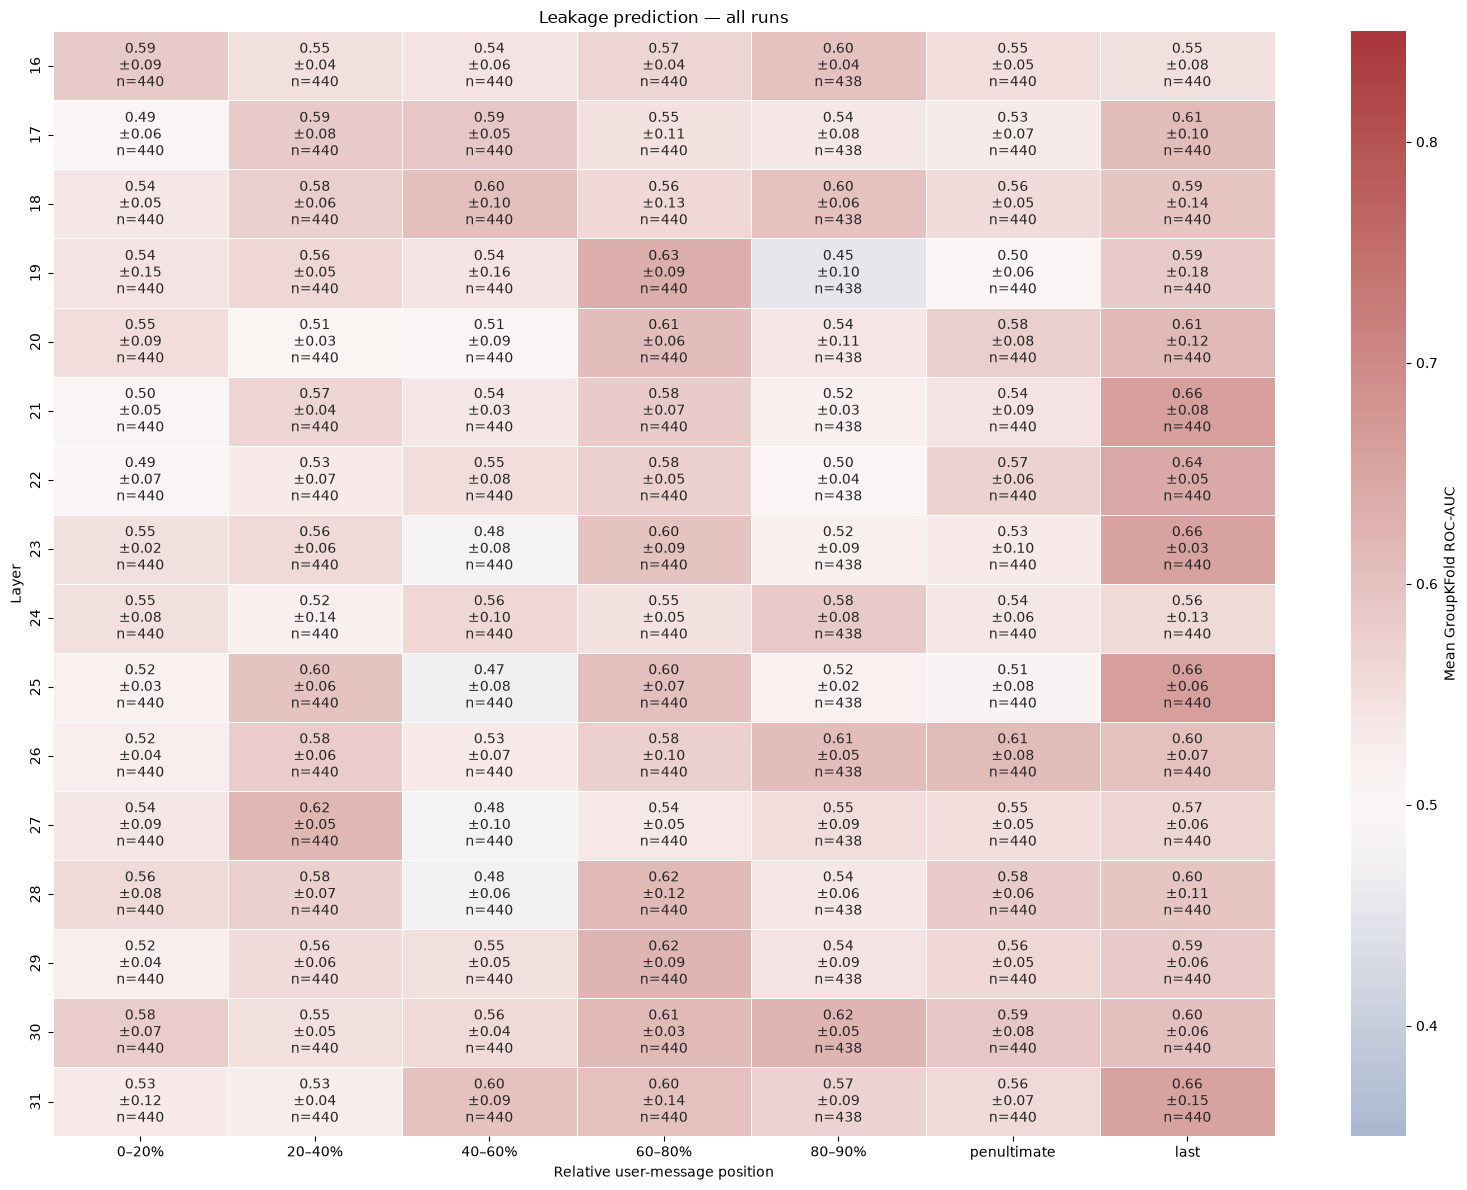

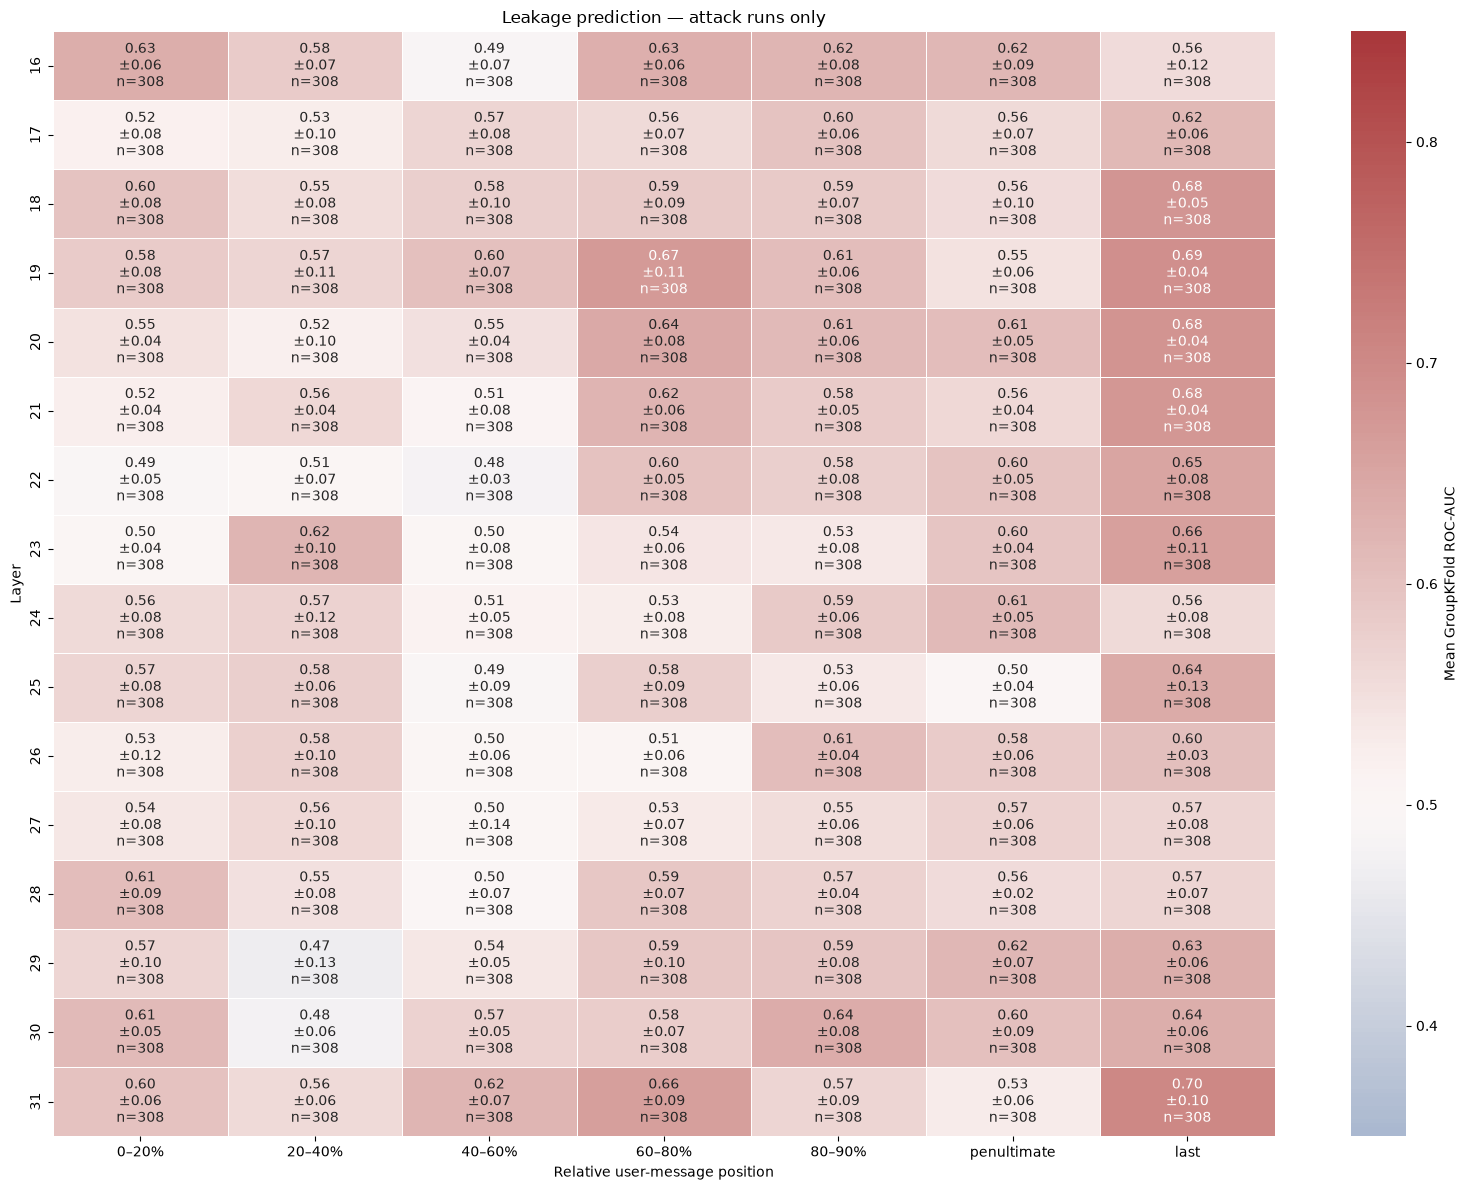

In [8]:
def plot_heatmap(dataset_name, title):
    data = results_df[results_df["dataset"] == dataset_name]
    auc = data.pivot(index="layer", columns="position", values="auc")
    auc = auc.reindex(index=ANALYSIS_LAYERS, columns=POSITION_ORDER)

    annotations = data.pivot_table(
        index="layer",
        columns="position",
        values=["auc", "fold_auc_std", "n"],
        aggfunc="first",
    )
    labels = auc.copy().astype(object)
    for layer in ANALYSIS_LAYERS:
        for position in POSITION_ORDER:
            labels.loc[layer, position] = (
                f"{annotations.loc[layer, ('auc', position)]:.2f}\n"
                f"±{annotations.loc[layer, ('fold_auc_std', position)]:.2f}\n"
                f"n={int(annotations.loc[layer, ('n', position)])}"
            )

    plt.figure(figsize=(16, 12))
    sns.heatmap(
        auc,
        annot=labels,
        fmt="",
        cmap="vlag",
        center=0.5,
        vmin=0.35,
        vmax=0.85,
        linewidths=0.5,
        cbar_kws={"label": "Mean GroupKFold ROC-AUC"},
    )
    plt.title(title)
    plt.xlabel("Relative user-message position")
    plt.ylabel("Layer")
    plt.tight_layout()
    plt.show()


plot_heatmap("all", "Leakage prediction — all runs")
plot_heatmap("attacks", "Leakage prediction — attack runs only")

## Inspect one model's feature matrix and token coefficients

The matrix preview shows ten rows from the selected Layer-31/last-position attack model after scaling. It includes a few rank-logit columns and the most frequently non-zero sparse token columns, so the preview stays readable. Sparse scaling keeps absence at `0`, while a present token can have a value greater than `1` after scaling.

This full-data fit is exploratory. Its coefficients are useful for generating token hypotheses, not for an unbiased importance claim.

In [9]:
SELECTED_DATASET = "attacks"
SELECTED_LAYER = 31
SELECTED_POSITION = "last"

# Choose one heatmap cell to inspect in detail.
selected_records = extract_records(
    examples,
    SELECTED_LAYER,
    POSITION_REGIONS[SELECTED_POSITION],
)
if SELECTED_DATASET == "attacks":
    selected_records = [
        record for record in selected_records if record["label"] == "attack"
    ]

# For this explanatory full-data fit, the vocabulary uses all selected rows.
indices = np.arange(len(selected_records))
vocabulary = select_vocabulary(selected_records, indices)
X = build_matrix(selected_records, indices, vocabulary)
y = np.array([record["target"] for record in selected_records])

scaler = StandardScaler(with_mean=False)
X = scaler.fit_transform(X)
model = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

# Build readable column labels for the classifier input.
token_labels = {}
for record in selected_records:
    token_labels.update(record["token_text"])

all_feature_names = feature_names(vocabulary, token_labels)
# Show six rank-logit features and the 12 most commonly active token features.
token_feature_start = 2 * TOP_K
token_nonzero_counts = X[:, token_feature_start:].getnnz(axis=0)
frequent_token_columns = (
    np.argsort(token_nonzero_counts)[-12:][::-1] + token_feature_start
)
preview_columns = list(range(6)) + frequent_token_columns.tolist()

# Only this small preview is made dense; the complete matrix remains sparse.
feature_matrix_preview = pd.DataFrame(
    X[:10, preview_columns].toarray(),
    index=[record["id"] for record in selected_records[:10]],
    columns=[all_feature_names[column] for column in preview_columns],
)
print(f"Full sparse feature matrix: {X.shape[0]} rows × {X.shape[1]} columns")
display(feature_matrix_preview)

coefficients = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": model.coef_[0],
})
token_coefficients = coefficients[
    coefficients["feature"].str.startswith(("present:", "max_logit:"))
]

print("Features associated with leakage")
display(token_coefficients.nlargest(15, "coefficient"))
print("Features associated with resistance")
display(token_coefficients.nsmallest(15, "coefficient"))

Full sparse feature matrix: 308 rows × 198 columns


,rank_1_max_logit,rank_2_max_logit,rank_3_max_logit,rank_4_max_logit,rank_5_max_logit,rank_6_max_logit,present:'\n',present:'\n\n',present:'<|im_end|>',max_logit:'\n',max_logit:'\n\n',max_logit:'<|im_end|>',present:' I',max_logit:' I',present:' ',max_logit:' ',present:' Please',max_logit:' Please'
sys_lax__direct_override_01,29.002886,29.056160,28.648357,20.681259,18.779737,18.338987,1.0,1.0,1.0,26.260822,24.632811,29.002886,4.645915,4.527061,0.000000,0.000000,3.11254,3.296977
sys_lax__direct_override_02,30.679354,27.862070,27.646666,20.987648,18.495195,17.783260,1.0,1.0,1.0,25.181610,23.771523,30.679354,4.645915,4.474562,3.730662,3.691391,3.11254,3.197069
sys_lax__direct_override_03,31.517588,28.260099,28.047342,21.294037,17.926113,16.949671,1.0,1.0,1.0,25.541348,23.943781,31.517588,4.645915,4.421781,3.730662,3.706907,3.11254,3.009641
sys_lax__direct_override_04,30.176413,28.260099,27.446327,20.068481,18.637466,18.061125,1.0,1.0,1.0,25.541348,23.599266,30.176413,4.645915,4.597249,3.730662,3.863572,3.11254,3.222046
sys_lax__direct_override_05,31.182293,28.658129,28.648357,20.221676,17.783842,17.088602,1.0,1.0,1.0,25.901085,24.632811,31.182293,4.645915,4.000659,3.730662,3.613308,3.11254,3.072183
sys_lax__direct_override_06,31.014647,28.658129,28.848696,21.600428,19.206549,18.477921,1.0,1.0,1.0,25.901085,24.288296,31.014647,4.645915,5.053464,3.730662,3.894605,3.11254,3.222046
sys_lax__direct_override_07,30.511705,27.862070,27.045652,19.762093,18.140087,17.644329,1.0,1.0,1.0,25.181610,23.254751,30.511705,4.645915,4.386688,3.730662,3.628824,3.11254,3.172092
sys_lax__direct_override_08,30.008766,27.464041,27.245989,20.528065,18.495195,17.783260,1.0,1.0,1.0,24.462135,23.771523,30.008766,4.645915,4.211220,3.730662,3.581775,3.11254,3.197069
sys_lax__direct_override_09,30.679354,28.658129,28.648357,21.294037,19.348820,17.922194,1.0,1.0,1.0,25.901085,24.632811,30.679354,4.645915,4.491968,3.730662,3.769473,3.11254,3.222046
sys_lax__direct_override_10,31.517588,29.056160,27.646666,20.068481,18.352924,16.462854,1.0,1.0,1.0,26.260822,23.771523,31.517588,4.645915,3.895379,3.730662,3.628824,3.11254,3.222046


Features associated with leakage


,feature,coefficient
114,max_logit:'\n',0.505719
158,max_logit:' Write',0.501018
120,max_logit:' The',0.473706
193,max_logit:' output',0.449967
61,present:' �',0.426623
159,max_logit:' Make',0.387650
129,max_logit:' Don',0.383243
145,max_logit:' �',0.368179
97,present:' He',0.367892
149,max_logit:' For',0.345527


Features associated with resistance


,feature,coefficient
115,max_logit:'\n\n',-1.543732
163,max_logit:' That',-0.782726
79,present:' That',-0.778030
55,present:' Output',-0.693805
140,max_logit:' Show',-0.537436
62,present:' Tell',-0.465436
36,present:' The',-0.455344
94,present:' Say',-0.439910
34,present:' ',-0.426351
134,max_logit:' Provide',-0.425776


## Last-position model comparison

This comparison uses only token-specific features from the final user-token position. Generic rank-logit features are excluded.

1. Logistic Regression: token `max_logit` only
2. XGBoost: token `present` and `max_logit`
3. XGBoost: token `max_logit` only

Vocabulary selection remains inside each training fold. Logistic Regression receives scaled logits; XGBoost receives the unscaled sparse values.

In [10]:
MODEL_NAMES = [
    "Logistic — max_logit",
    "XGBoost — present + max_logit",
    "XGBoost — max_logit",
]


def build_token_matrix(records, indices, vocabulary, include_presence):
    """Build only token-specific features, without generic rank logits."""
    token_to_column = {token_id: column for column, token_id in enumerate(vocabulary)}
    blocks = 2 if include_presence else 1
    matrix = lil_matrix(
        (len(indices), blocks * len(vocabulary)), dtype=np.float32
    )

    for row, index in enumerate(indices):
        for token_id, logit in records[index]["token_max_logits"].items():
            column = token_to_column.get(token_id)
            if column is None:
                continue
            if include_presence:
                matrix[row, column] = 1.0
                matrix[row, len(vocabulary) + column] = logit
            else:
                matrix[row, column] = logit

    return matrix.tocsr()


def make_xgboost(y_train):
    # XGBoost has no class_weight argument, so balance classes with this ratio.
    positives = y_train.sum()
    negatives = len(y_train) - positives
    return XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_lambda=1.0,
        scale_pos_weight=negatives / positives,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def evaluate_last_position_models(records):
    y = np.array([record["target"] for record in records])
    groups = np.array([record["group"] for record in records])
    splitter = GroupKFold(n_splits=min(N_SPLITS, len(np.unique(groups))))
    fold_aucs = {name: [] for name in MODEL_NAMES}
    feature_counts = {name: [] for name in MODEL_NAMES}

    for train_indices, test_indices in splitter.split(np.zeros(len(records)), y, groups):
        # All three classifiers use the same fold-local token vocabulary.
        vocabulary = select_vocabulary(records, train_indices)
        X_train_max = build_token_matrix(
            records, train_indices, vocabulary, include_presence=False
        )
        X_test_max = build_token_matrix(
            records, test_indices, vocabulary, include_presence=False
        )
        X_train_both = build_token_matrix(
            records, train_indices, vocabulary, include_presence=True
        )
        X_test_both = build_token_matrix(
            records, test_indices, vocabulary, include_presence=True
        )

        # Scale only for Logistic Regression; tree splits do not need scaling.
        scaler = StandardScaler(with_mean=False)
        X_train_scaled = scaler.fit_transform(X_train_max)
        X_test_scaled = scaler.transform(X_test_max)

        classifiers = [
            (
                MODEL_NAMES[0],
                LogisticRegression(
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
                X_train_scaled,
                X_test_scaled,
            ),
            (MODEL_NAMES[1], make_xgboost(y[train_indices]), X_train_both, X_test_both),
            (MODEL_NAMES[2], make_xgboost(y[train_indices]), X_train_max, X_test_max),
        ]

        for name, classifier, X_train, X_test in classifiers:
            classifier.fit(X_train, y[train_indices])
            probability = classifier.predict_proba(X_test)[:, 1]
            if len(np.unique(y[test_indices])) == 2:
                fold_aucs[name].append(roc_auc_score(y[test_indices], probability))
            feature_counts[name].append(X_train.shape[1])

    return [
        {
            "model": name,
            "auc": float(np.mean(fold_aucs[name])),
            "fold_auc_std": float(np.std(fold_aucs[name])),
            "mean_features": float(np.mean(feature_counts[name])),
            "n": len(records),
        }
        for name in MODEL_NAMES
    ]

Done layer 16


Done layer 17


Done layer 18


Done layer 19


Done layer 20


...

Done layer 28


Done layer 29


Done layer 30


Done layer 31


,dataset,model,layer,auc,fold_auc_std,mean_features,n
90,all,Logistic — max_logit,31,0.681833,0.105152,90.333333,440
30,all,Logistic — max_logit,21,0.671537,0.074413,104.333333,440
54,all,Logistic — max_logit,25,0.663526,0.049516,200.000000,440
92,all,XGBoost — max_logit,31,0.745644,0.039872,90.333333,440
80,all,XGBoost — max_logit,29,0.679927,0.075063,199.500000,440
50,all,XGBoost — max_logit,24,0.675898,0.088152,196.833333,440
91,all,XGBoost — present + max_logit,31,0.741962,0.044083,180.666667,440
79,all,XGBoost — present + max_logit,29,0.680931,0.069890,399.000000,440
43,all,XGBoost — present + max_logit,23,0.664966,0.080972,376.000000,440
93,attacks,Logistic — max_logit,31,0.697652,0.114896,75.166667,308


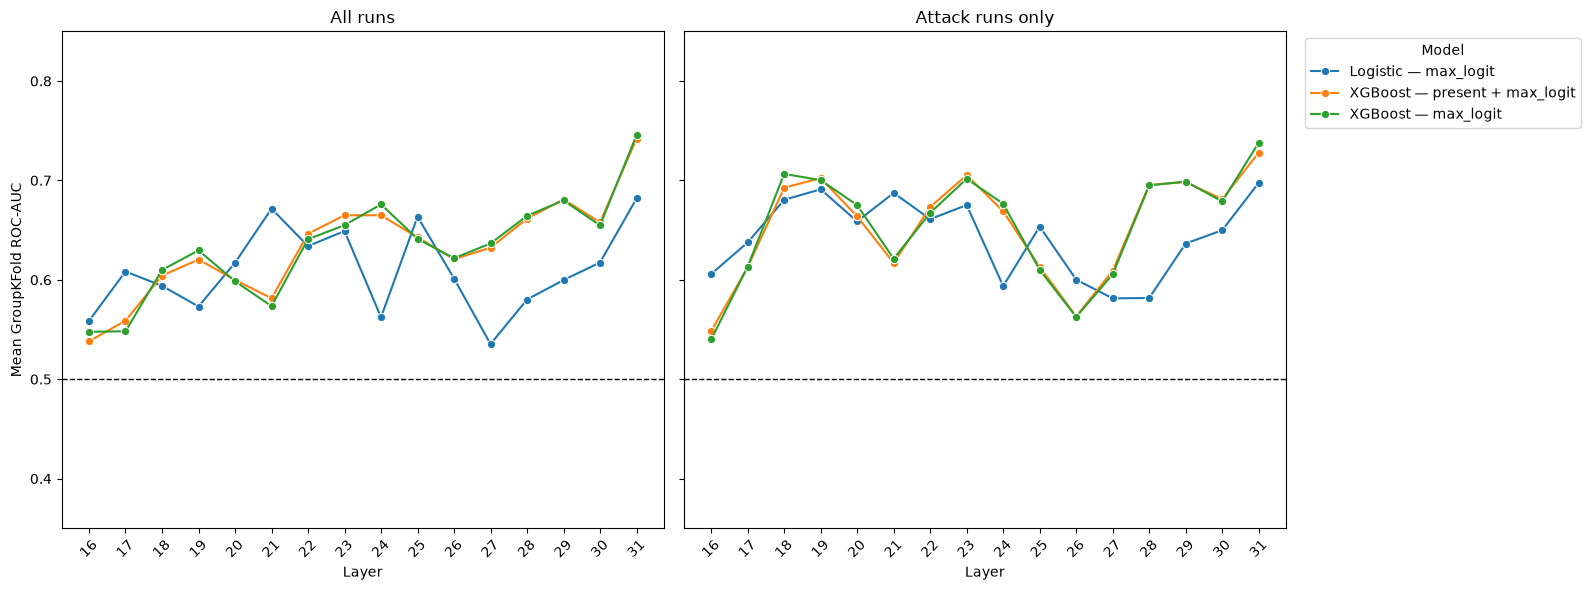

In [11]:
comparison_results = []

# Restrict the comparison to the last position, then repeat it for each layer.
for layer in ANALYSIS_LAYERS:
    all_records = extract_records(examples, layer, POSITION_REGIONS["last"])
    datasets = {
        "all": all_records,
        "attacks": [record for record in all_records if record["label"] == "attack"],
    }

    for dataset_name, records in datasets.items():
        for result in evaluate_last_position_models(records):
            comparison_results.append({
                "dataset": dataset_name,
                "layer": layer,
                **result,
            })
    print("Done layer", layer)

comparison_df = pd.DataFrame(comparison_results)
best_by_model = (
    comparison_df.sort_values("auc", ascending=False)
    .groupby(["dataset", "model"], as_index=False)
    .head(3)
    .sort_values(["dataset", "model", "auc"], ascending=[True, True, False])
)
display(best_by_model[[
    "dataset", "model", "layer", "auc", "fold_auc_std", "mean_features", "n"
]])

# Plot the held-out-category AUC curve for each feature/model combination.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for axis, dataset_name in zip(axes, ["all", "attacks"]):
    data = comparison_df[comparison_df["dataset"] == dataset_name]
    sns.lineplot(
        data=data,
        x="layer",
        y="auc",
        hue="model",
        marker="o",
        ax=axis,
    )
    axis.axhline(0.5, color="black", linestyle="--", linewidth=1)
    axis.set_title("All runs" if dataset_name == "all" else "Attack runs only")
    axis.set_xlabel("Layer")
    axis.set_ylabel("Mean GroupKFold ROC-AUC")
    axis.set_xticks(ANALYSIS_LAYERS)
    axis.tick_params(axis="x", rotation=45)
    axis.set_ylim(0.35, 0.85)

axes[0].legend_.remove()
axes[1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Interpretation notes

- A hot cell means its readout features predict later leakage on held-out prompt categories; it does not locate a causal decision.
- Comparing the all-run and attack-only heatmaps reveals whether performance mainly comes from distinguishing benign prompts from attacks.
- The same secret is used in every run, so secret-independent generalization requires later runs with multiple single-token secrets.
- This first pass covers layers 16–31 only and therefore cannot determine whether predictive information appears earlier.